# Graph EDA — GCN Insider Threat Detection (CMU CERT r5.2)

Exploratory analysis of preprocessed session graphs.

**Data layout**
- 31 `graph_chunk_*.pt` files in `data/processed/r5.2/`
- Each graph = one user session with one position masked
- `g.x` — node features, shape `[N, 54]` (logon·4 | device·6 | file·16 | email·22 | http·6)
- `g.edge_index` — sequential + activity-type edges
- `g.y_act` — masked activity code (`type_id × 24 + hour`)
- `g.y_label` — 1 if masked event is malicious, else 0

In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import random
from pathlib import Path
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CHUNK_DIR = Path('../data/processed/r5.2')
CHUNKS    = sorted(CHUNK_DIR.glob('graph_chunk_*.pt'))
print(f'Found {len(CHUNKS)} chunk files')

ACTIVITY_NAMES = [
    'File Open', 'File Write', 'Logoff', 'Logon',
    'Connect', 'Disconnect', 'Receive', 'Send', 'WWW Visit'
]
FEAT_GROUPS = [
    ('Logon',  0,  4,  '#4C72B0'),
    ('Device', 4,  10, '#55A868'),
    ('File',   10, 26, '#C44E52'),
    ('Email',  26, 48, '#937860'),
    ('HTTP',   48, 54, '#FFBE86'),
]

Found 23 chunk files


## 1. Dataset Scan — Build Stratified Sample

Scan all 31 chunks, collect global statistics, keep all malicious graphs
and a random sample of normal ones.

In [4]:
random.seed(42)
NORMAL_PER_CHUNK = 200   # ~6,200 normal total

chunk_stats   = []
sample_normal = []
sample_mal    = []

for path in CHUNKS:
    gs     = torch.load(path, weights_only=False)
    normal = [g for g in gs if g.y_label.item() == 0]
    mal    = [g for g in gs if g.y_label.item() == 1]
    chunk_stats.append({'chunk': path.stem, 'total': len(gs),
                        'malicious': len(mal), 'normal': len(normal)})
    sample_mal.extend(mal)
    sample_normal.extend(random.sample(normal, min(NORMAL_PER_CHUNK, len(normal))))

stats_df = pd.DataFrame(chunk_stats)
TOTAL    = stats_df['total'].sum()
N_MAL    = stats_df['malicious'].sum()
N_NOR    = stats_df['normal'].sum()

print(f'Total graphs : {TOTAL:,}')
print(f'Normal       : {N_NOR:,}  ({N_NOR/TOTAL*100:.2f}%)')
print(f'Malicious    : {N_MAL:,}  ({N_MAL/TOTAL*100:.4f}%)')
print(f'Imbalance    : {N_NOR/N_MAL:.0f} : 1')
print()
print(f'Sample — normal: {len(sample_normal):,}, malicious: {len(sample_mal):,}')
all_sample = sample_normal + sample_mal

Total graphs : 1,208,596
Normal       : 1,206,512  (99.83%)
Malicious    : 2,084  (0.1724%)
Imbalance    : 579 : 1

Sample — normal: 4,600, malicious: 2,084


## 2. Class Imbalance

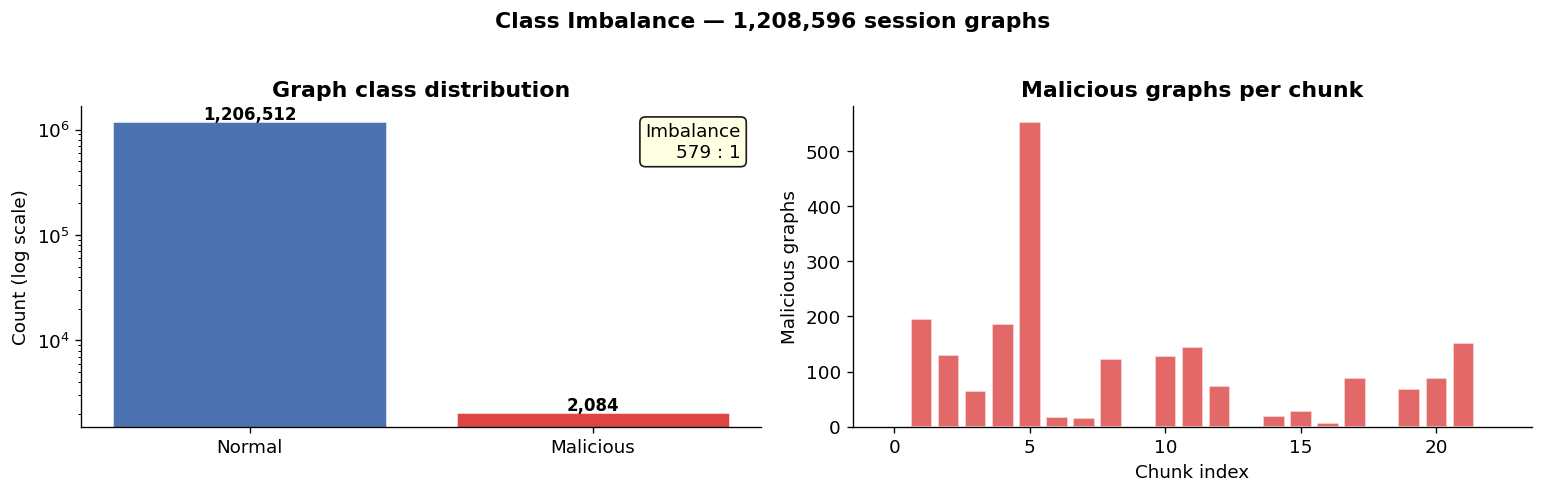

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Log-scale bar
bars = axes[0].bar(['Normal', 'Malicious'], [N_NOR, N_MAL],
                   color=['#4C72B0', '#DD4444'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, [N_NOR, N_MAL]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.05,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_yscale('log')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Graph class distribution', fontweight='bold')
axes[0].text(0.97, 0.95, f'Imbalance\n{N_NOR/N_MAL:.0f} : 1',
             transform=axes[0].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# Malicious count per chunk
axes[1].bar(range(len(stats_df)), stats_df['malicious'],
            color='#DD4444', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Chunk index')
axes[1].set_ylabel('Malicious graphs')
axes[1].set_title('Malicious graphs per chunk', fontweight='bold')
axes[1].set_xticks(range(0, len(stats_df), 5))

plt.suptitle(f'Class Imbalance — {TOTAL:,} session graphs', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Graph Size Distribution (Nodes & Edges)

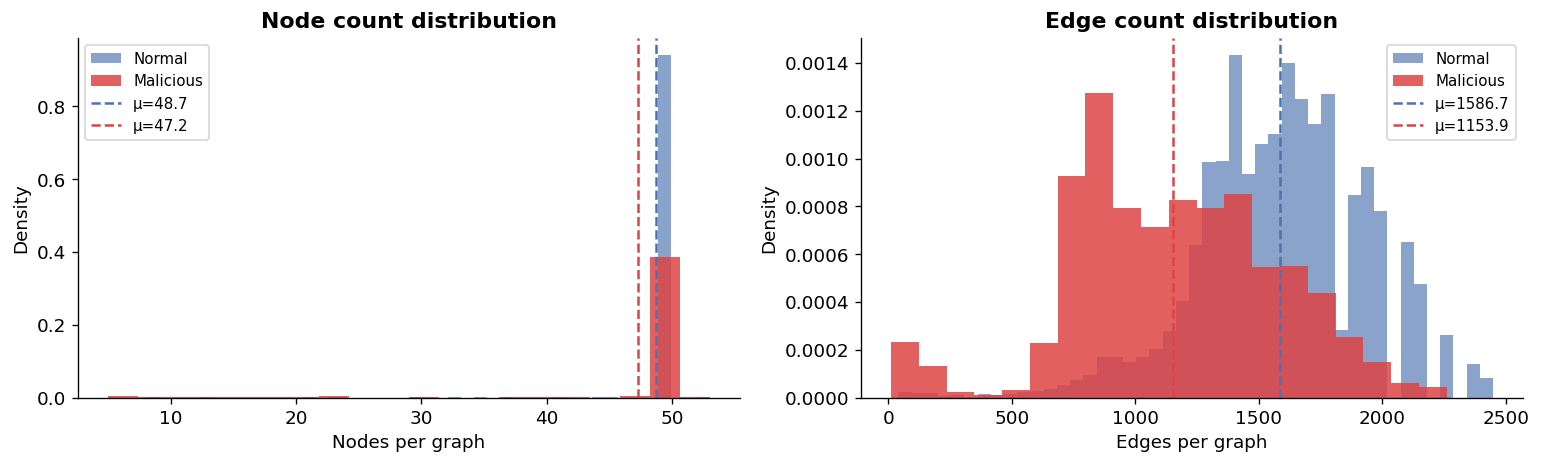

Normal    nodes: 48.7 ± 2.8  | edges: 1587 ± 343
Malicious nodes: 47.2 ± 7.6  | edges: 1154 ± 423


In [6]:
node_n = [g.x.shape[0]          for g in sample_normal]
node_m = [g.x.shape[0]          for g in sample_mal]
edge_n = [g.edge_index.shape[1] for g in sample_normal]
edge_m = [g.edge_index.shape[1] for g in sample_mal]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, nn, nm, xlabel, title in [
    (axes[0], node_n, node_m, 'Nodes per graph', 'Node count distribution'),
    (axes[1], edge_n, edge_m, 'Edges per graph', 'Edge count distribution'),
]:
    ax.hist(nn, bins=45, color='#4C72B0', alpha=0.65, label='Normal', density=True)
    ax.hist(nm, bins=20, color='#DD4444', alpha=0.85, label='Malicious', density=True)
    ax.axvline(np.mean(nn), color='#4C72B0', linestyle='--', lw=1.5,
               label=f'μ={np.mean(nn):.1f}')
    ax.axvline(np.mean(nm), color='#DD4444', linestyle='--', lw=1.5,
               label=f'μ={np.mean(nm):.1f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Normal    nodes: {np.mean(node_n):.1f} ± {np.std(node_n):.1f}  '
      f'| edges: {np.mean(edge_n):.0f} ± {np.std(edge_n):.0f}')
print(f'Malicious nodes: {np.mean(node_m):.1f} ± {np.std(node_m):.1f}  '
      f'| edges: {np.mean(edge_m):.0f} ± {np.std(edge_m):.0f}')

## 4. Masked Activity — Type × Hour Heatmap

`activity_code = type_id × 24 + hour` — which activity slot is being predicted?

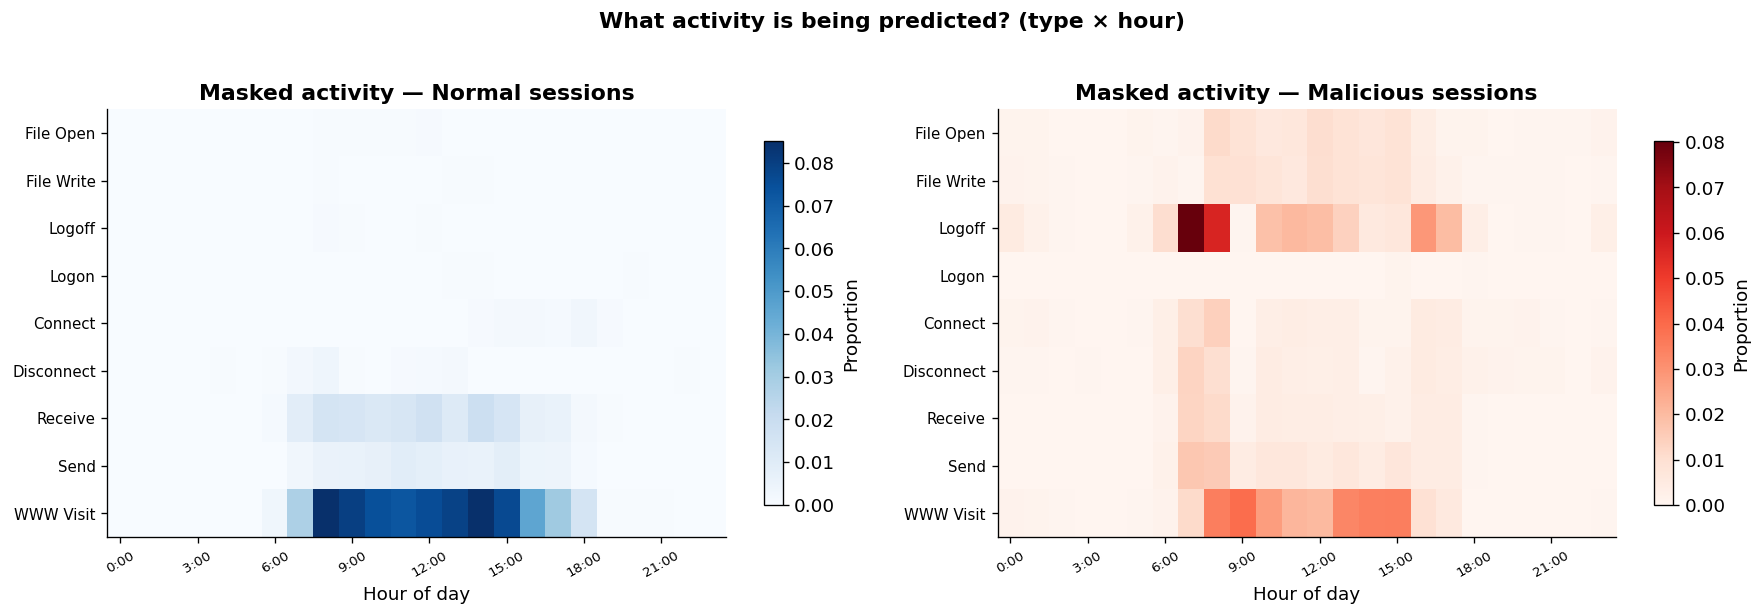

In [7]:
def activity_heatmap(graphs):
    mat = np.zeros((len(ACTIVITY_NAMES), 24))
    for g in graphs:
        code = g.y_act.item()
        t, h = code // 24, code % 24
        if t < len(ACTIVITY_NAMES):
            mat[t, h] += 1
    return mat

mat_n = activity_heatmap(sample_normal)
mat_m = activity_heatmap(sample_mal)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, mat, title, cmap in [
    (axes[0], mat_n / mat_n.sum(), 'Normal sessions',    'Blues'),
    (axes[1], mat_m / max(mat_m.sum(), 1), 'Malicious sessions', 'Reds'),
]:
    im = ax.imshow(mat, aspect='auto', cmap=cmap, interpolation='nearest')
    ax.set_yticks(range(len(ACTIVITY_NAMES)))
    ax.set_yticklabels(ACTIVITY_NAMES, fontsize=9)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f'{h}:00' for h in range(0, 24, 3)], rotation=30, fontsize=8)
    ax.set_xlabel('Hour of day')
    ax.set_title(f'Masked activity — {title}', fontweight='bold')
    plt.colorbar(im, ax=ax, label='Proportion', shrink=0.85)

plt.suptitle('What activity is being predicted? (type × hour)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Graph Visualisation — Normal vs Malicious

Node colour = dominant feature group (Logon / Device / File / Email / HTTP).  
**Blue arrows** = sequential edges.  **Orange dashed** = activity-type (implicit) edges.

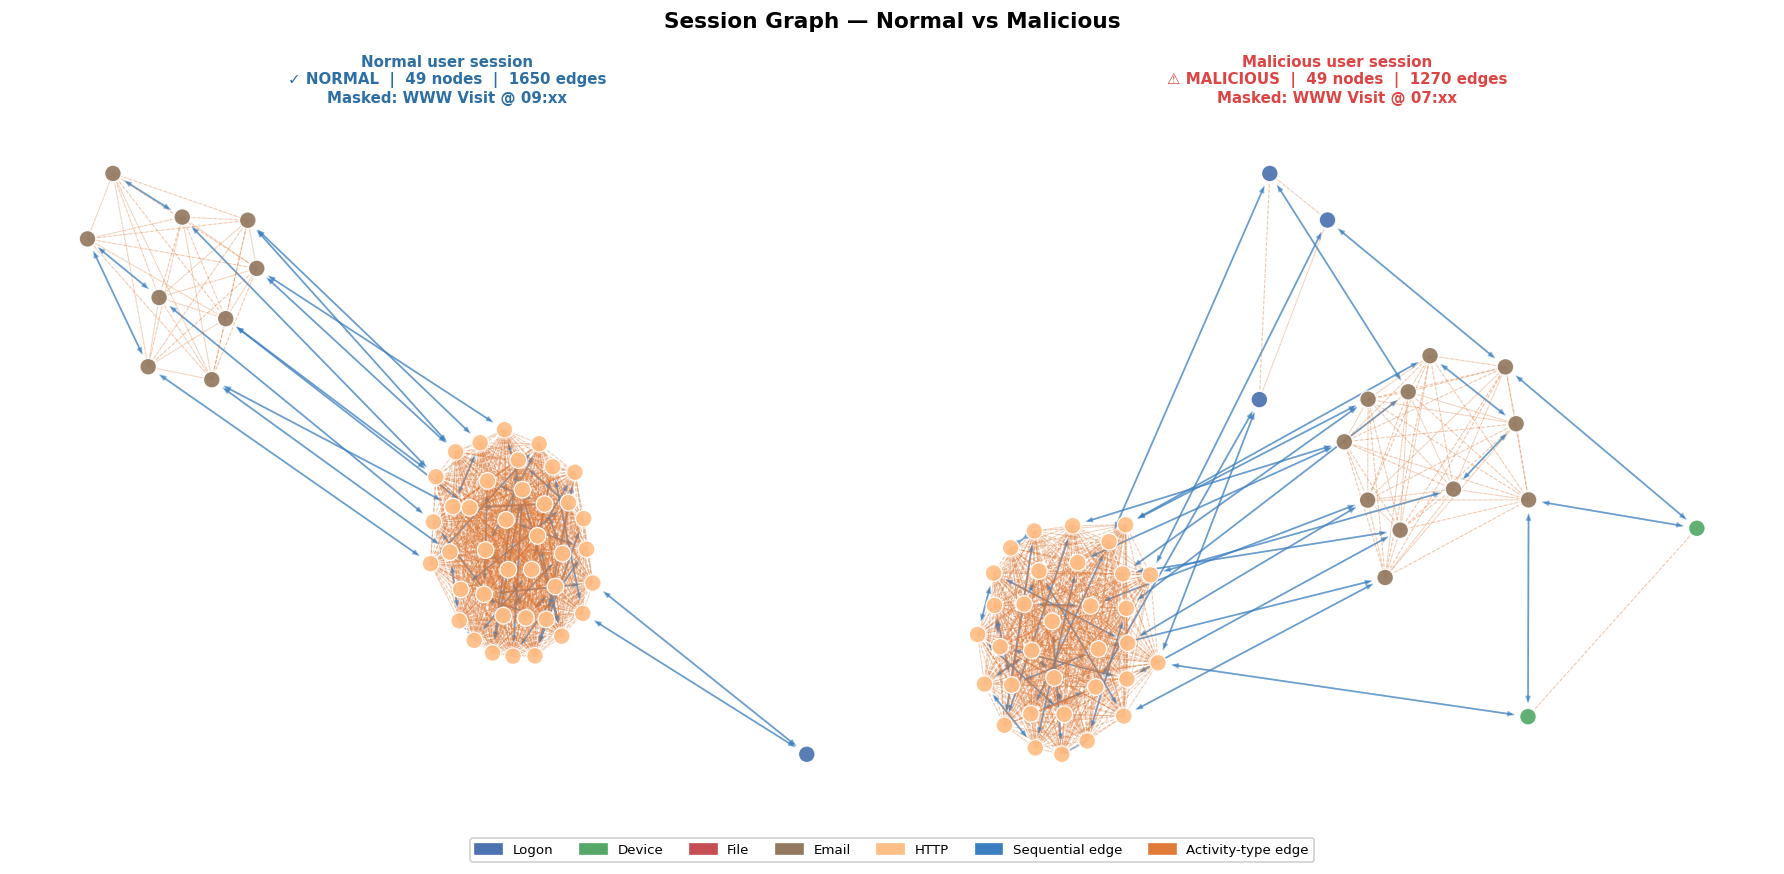

In [8]:
node_patches = [mpatches.Patch(color=c, label=n) for n, _, _, c in FEAT_GROUPS]
edge_patches = [
    mpatches.Patch(color='#3A7EBF', label='Sequential edge'),
    mpatches.Patch(color='#E07B39', label='Activity-type edge'),
]

def node_color(feat_vec):
    best, best_val = FEAT_GROUPS[-1][3], -1.0
    for _, s, e, color in FEAT_GROUPS:
        val = float(np.abs(feat_vec[s:e]).sum())
        if val > best_val:
            best_val = val
            best = color
    return best

def draw_graph(g, ax, title=''):
    src = g.edge_index[0].tolist()
    dst = g.edge_index[1].tolist()
    n   = g.x.shape[0]
    is_mal = g.y_label.item()

    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    for s, d in zip(src, dst):
        G.add_edge(s, d, etype='seq' if abs(s-d)==1 else 'act')

    ncolors  = [node_color(g.x[i].numpy()) for i in range(n)]
    seq_e    = [(u,v) for u,v,d in G.edges(data=True) if d['etype']=='seq']
    act_e    = [(u,v) for u,v,d in G.edges(data=True) if d['etype']=='act']
    pos      = nx.spring_layout(G, seed=42, k=1.8/max(np.sqrt(n), 1))

    nx.draw_networkx_edges(G, pos, edgelist=seq_e, ax=ax,
                           alpha=0.5, arrows=True, arrowsize=6,
                           edge_color='#3A7EBF', width=1.0)
    nx.draw_networkx_edges(G, pos, edgelist=act_e, ax=ax,
                           alpha=0.25, arrows=False,
                           edge_color='#E07B39', width=0.6, style='dashed')
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=ncolors,
                           node_size=100, alpha=0.92,
                           linewidths=0.8, edgecolors='white')

    code     = g.y_act.item()
    act_name = ACTIVITY_NAMES[code//24] if (code//24)<len(ACTIVITY_NAMES) else f'Act{code//24}'
    border   = '#DD4444' if is_mal else '#2E6FA3'
    for sp in ax.spines.values():
        sp.set_edgecolor(border)
        sp.set_linewidth(2.5)
    ax.set_title(
        f"{title}\n{'⚠ MALICIOUS' if is_mal else '✓ NORMAL'}"
        f"  |  {n} nodes  |  {len(src)} edges\n"
        f"Masked: {act_name} @ {code%24:02d}:xx",
        fontweight='bold', color=border, fontsize=9
    )
    ax.axis('off')

random.seed(13)
eg_n = random.choice(sample_normal)
eg_m = random.choice(sample_mal)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
draw_graph(eg_n, axes[0], 'Normal user session')
draw_graph(eg_m, axes[1], 'Malicious user session')
fig.legend(handles=node_patches+edge_patches,
           loc='lower center', ncol=7, fontsize=8,
           bbox_to_anchor=(0.5, -0.04), framealpha=0.9)
plt.suptitle('Session Graph — Normal vs Malicious', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Edge Type Breakdown (Sequential vs Activity-Type)

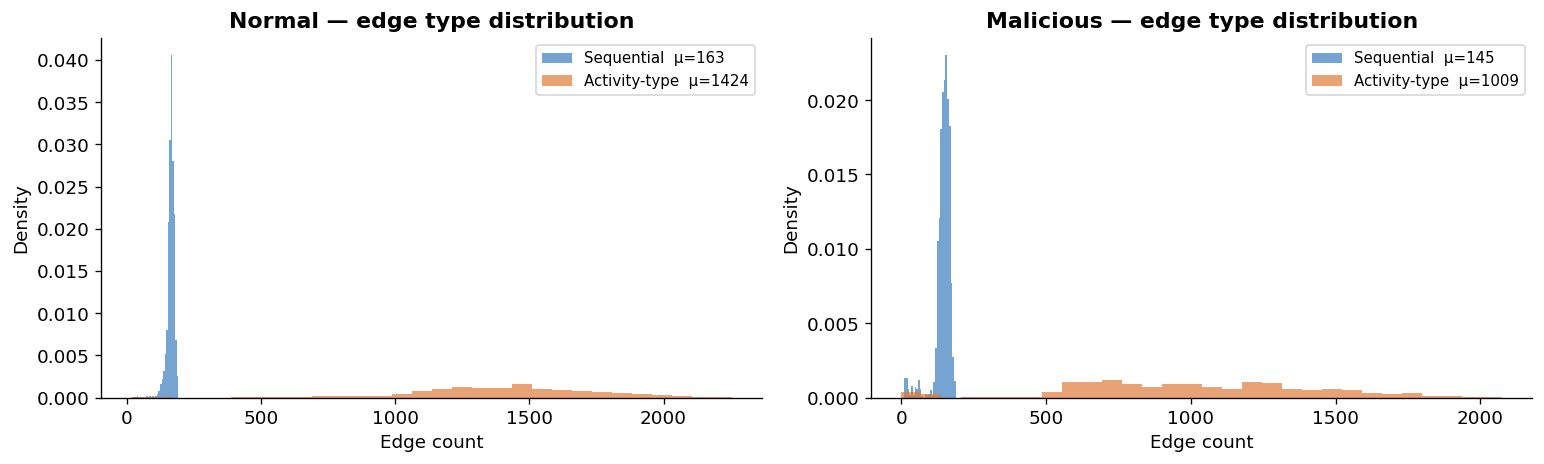

In [9]:
def edge_type_counts(graphs):
    seq, act = [], []
    for g in graphs:
        s = g.edge_index[0].tolist()
        d = g.edge_index[1].tolist()
        n_seq = sum(1 for a, b in zip(s, d) if abs(a-b)==1)
        seq.append(n_seq)
        act.append(len(s) - n_seq)
    return seq, act

seq_n, act_n = edge_type_counts(sample_normal)
seq_m, act_m = edge_type_counts(sample_mal)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, seq, act, label in [
    (axes[0], seq_n, act_n, 'Normal'),
    (axes[1], seq_m, act_m, 'Malicious'),
]:
    ax.hist(seq, bins=30, alpha=0.7, color='#3A7EBF',
            label=f'Sequential  μ={np.mean(seq):.0f}', density=True)
    ax.hist(act, bins=30, alpha=0.7, color='#E07B39',
            label=f'Activity-type  μ={np.mean(act):.0f}', density=True)
    ax.set_xlabel('Edge count')
    ax.set_ylabel('Density')
    ax.set_title(f'{label} — edge type distribution', fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. Node Degree Distribution

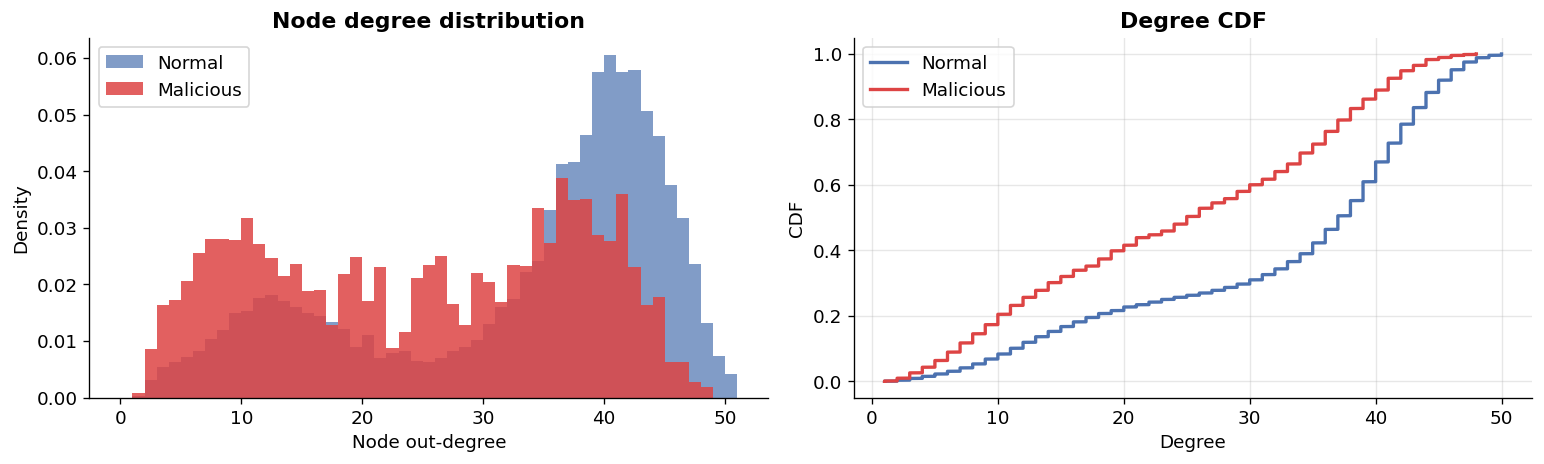

Normal    degree: mean=32.6, median=37, max=50
Malicious degree: mean=24.4, median=25, max=48


In [10]:
def degree_seq(graphs):
    degs = []
    for g in graphs:
        counts = Counter(g.edge_index[0].tolist())
        degs.extend(counts.values())
    return degs

deg_n = degree_seq(sample_normal)
deg_m = degree_seq(sample_mal)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
max_deg = max(max(deg_n), max(deg_m))
bins = range(0, max_deg+2)

axes[0].hist(deg_n, bins=bins, density=True, color='#4C72B0', alpha=0.7, label='Normal')
axes[0].hist(deg_m, bins=bins, density=True, color='#DD4444', alpha=0.85, label='Malicious')
axes[0].set_xlabel('Node out-degree')
axes[0].set_ylabel('Density')
axes[0].set_title('Node degree distribution', fontweight='bold')
axes[0].legend()

for data, label, color in [(deg_n,'Normal','#4C72B0'),(deg_m,'Malicious','#DD4444')]:
    sd = np.sort(data)
    axes[1].plot(sd, np.arange(1, len(sd)+1)/len(sd), color=color, label=label, lw=2)
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('CDF')
axes[1].set_title('Degree CDF', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Normal    degree: mean={np.mean(deg_n):.1f}, median={np.median(deg_n):.0f}, max={max(deg_n)}')
print(f'Malicious degree: mean={np.mean(deg_m):.1f}, median={np.median(deg_m):.0f}, max={max(deg_m)}')

## 8. Feature Space — PCA (Mean-Pooled Node Features)

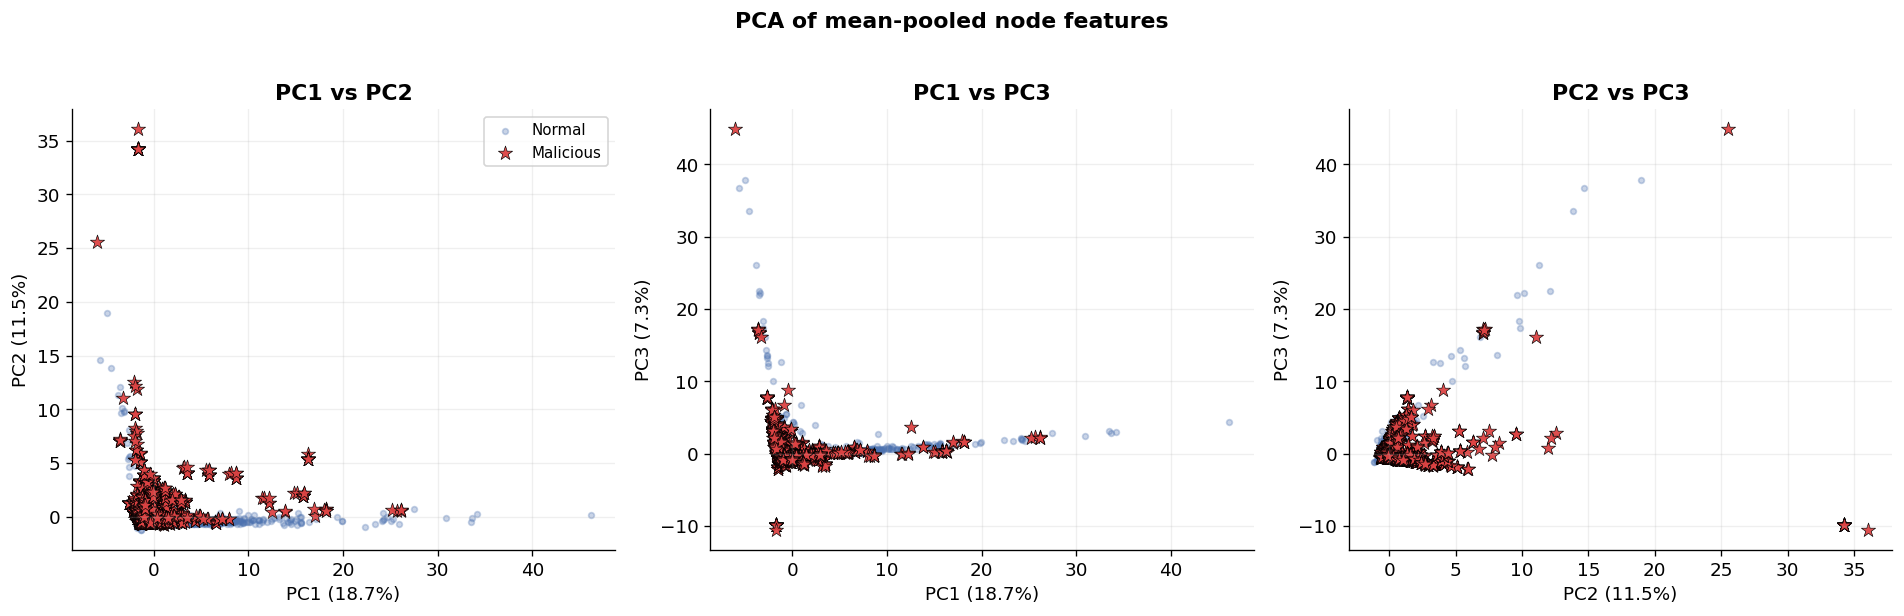

In [11]:
def graph_to_vec(g):
    return g.x.mean(dim=0).numpy()

X_n = np.array([graph_to_vec(g) for g in sample_normal])
X_m = np.array([graph_to_vec(g) for g in sample_mal])
X   = np.vstack([X_n, X_m])
y   = np.array([0]*len(X_n) + [1]*len(X_m))

X_sc  = StandardScaler().fit_transform(X)
pca   = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_sc)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

kw_n = dict(c='#4C72B0', alpha=0.3, s=12, label='Normal')
kw_m = dict(c='#DD4444', alpha=0.95, s=80, marker='*', label='Malicious',
            edgecolors='black', linewidths=0.4)

for ax, (i, j) in zip(axes, [(0,1),(0,2),(1,2)]):
    ax.scatter(X_pca[y==0,i], X_pca[y==0,j], **kw_n)
    ax.scatter(X_pca[y==1,i], X_pca[y==1,j], **kw_m)
    ax.set_xlabel(f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)')
    ax.set_ylabel(f'PC{j+1} ({pca.explained_variance_ratio_[j]*100:.1f}%)')
    ax.set_title(f'PC{i+1} vs PC{j+1}', fontweight='bold')
    ax.grid(alpha=0.2)

axes[0].legend(fontsize=9)
plt.suptitle('PCA of mean-pooled node features', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Feature Group Activation — Normal vs Malicious

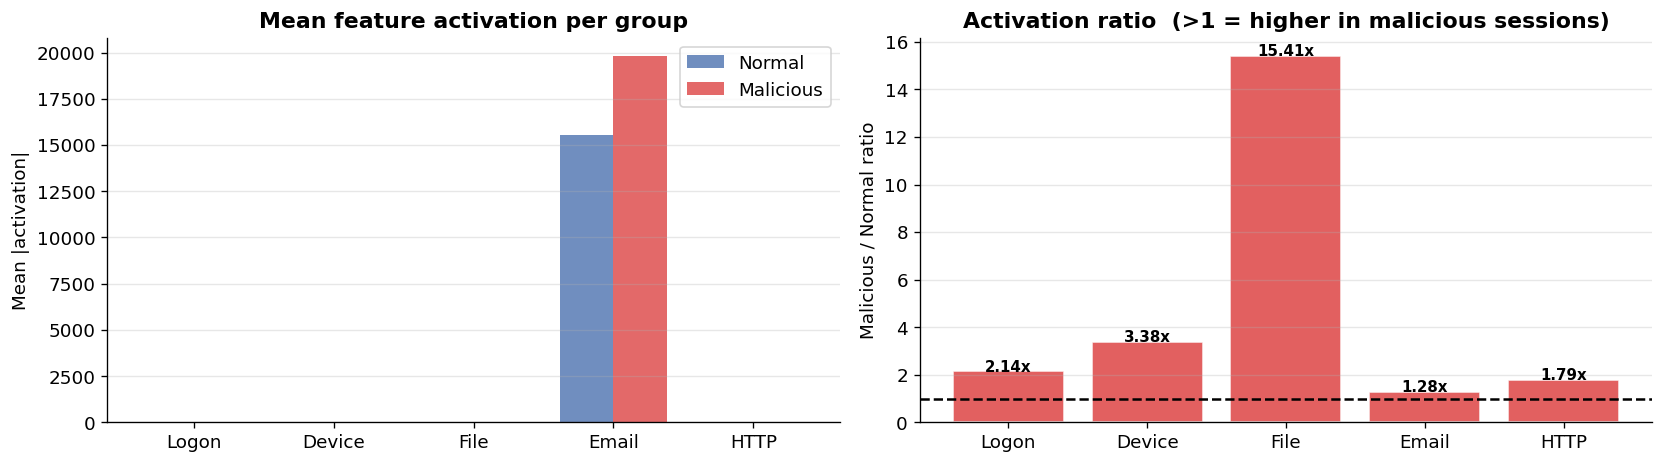

In [12]:
def mean_activation(graphs):
    X = torch.cat([g.x for g in graphs], dim=0).numpy()
    return {name: float(np.abs(X[:, s:e]).mean()) for name, s, e, _ in FEAT_GROUPS}

vals_n = mean_activation(sample_normal)
vals_m = mean_activation(sample_mal)
names  = [f[0] for f in FEAT_GROUPS]
x      = np.arange(len(names))
w      = 0.38

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(x-w/2, [vals_n[n] for n in names], w, label='Normal',    color='#4C72B0', alpha=0.8)
axes[0].bar(x+w/2, [vals_m[n] for n in names], w, label='Malicious', color='#DD4444', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names)
axes[0].set_ylabel('Mean |activation|')
axes[0].set_title('Mean feature activation per group', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

ratios = [vals_m[n]/(vals_n[n]+1e-9) for n in names]
bar_colors = ['#DD4444' if r>1 else '#4C72B0' for r in ratios]
axes[1].bar(names, ratios, color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].axhline(1.0, color='black', linestyle='--', lw=1.5)
axes[1].set_ylabel('Malicious / Normal ratio')
axes[1].set_title('Activation ratio  (>1 = higher in malicious sessions)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, r in enumerate(ratios):
    axes[1].text(i, r+0.01, f'{r:.2f}x', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Gallery — Six Malicious Session Graphs

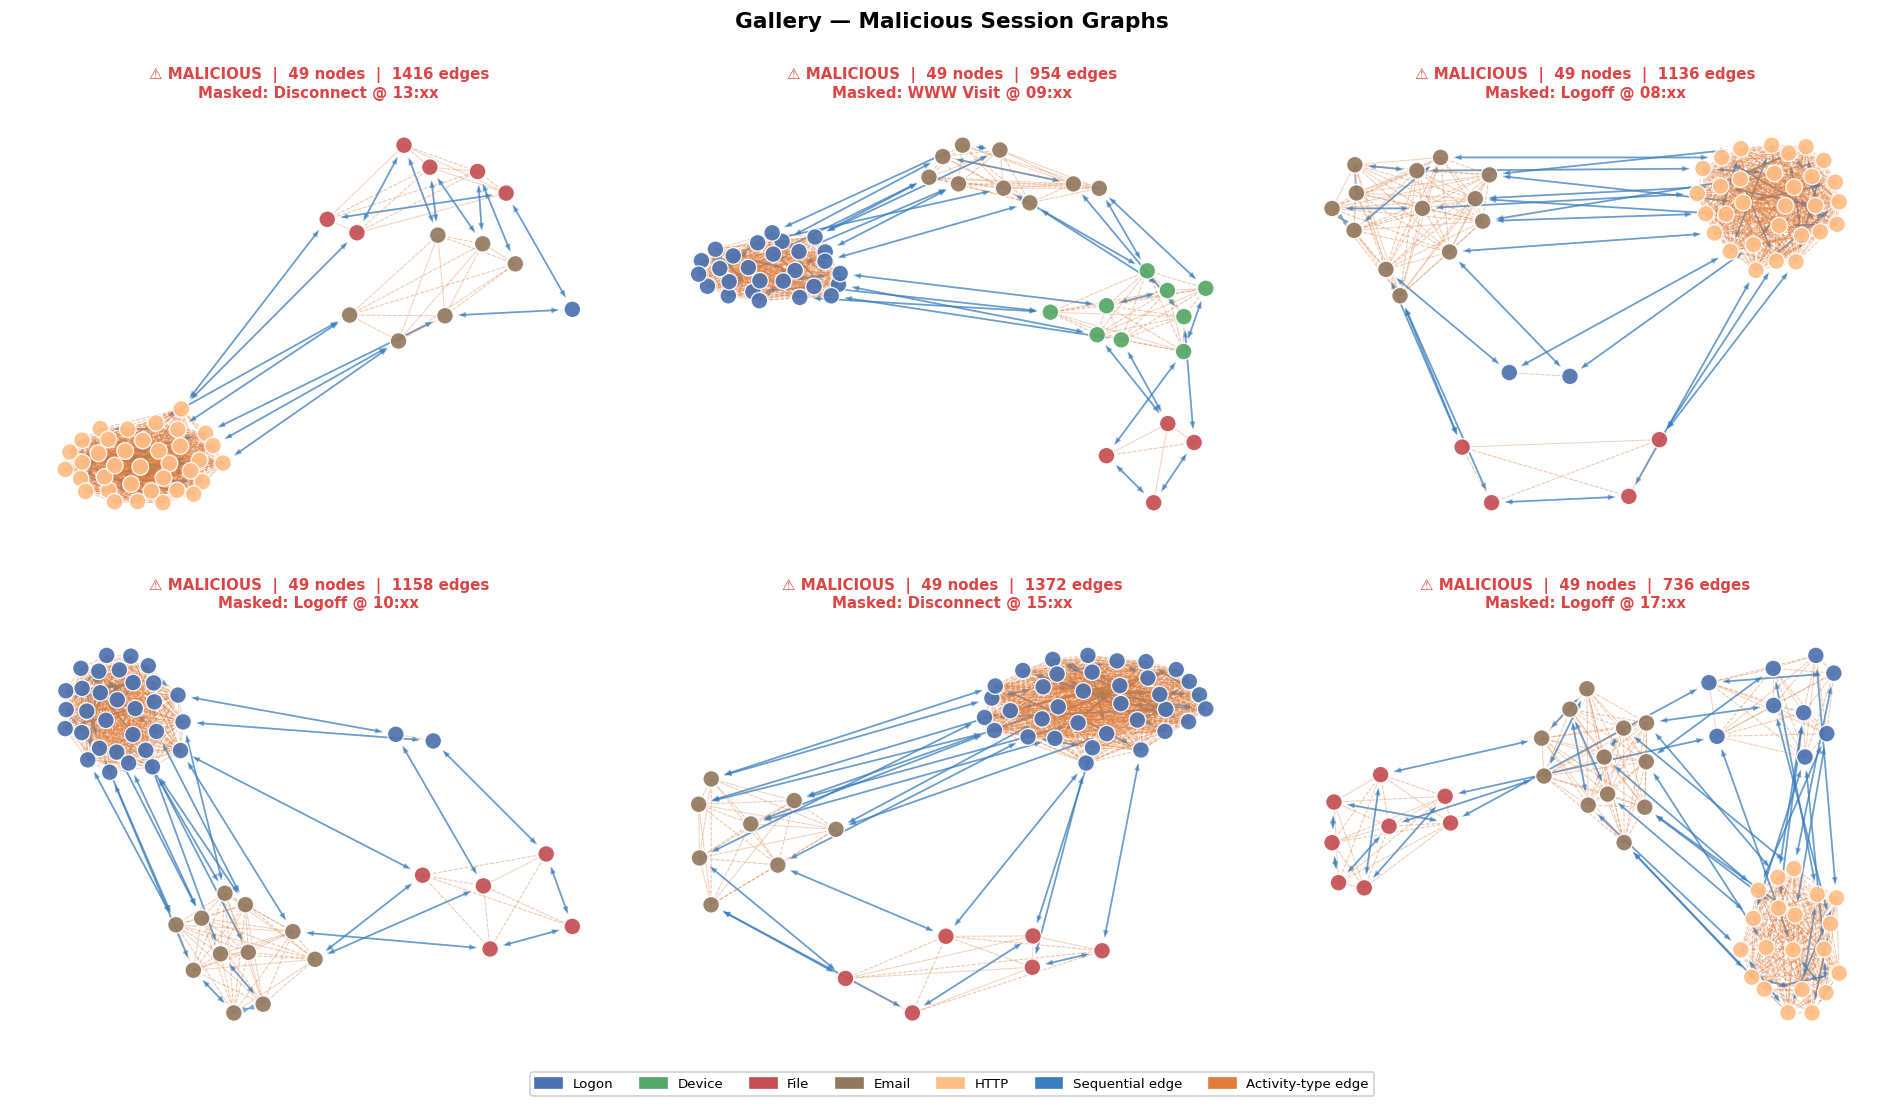

In [13]:
random.seed(7)
examples = random.sample(sample_mal, min(6, len(sample_mal)))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, g in zip(axes.flat, examples):
    draw_graph(g, ax)

fig.legend(handles=node_patches+edge_patches,
           loc='lower center', ncol=7, fontsize=8,
           bbox_to_anchor=(0.5, -0.03), framealpha=0.9)
plt.suptitle('Gallery — Malicious Session Graphs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()